# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.integrate import quad

G = 6.67e-11 # m^3 kg^-1 s^-2
M_E = 5.9e24 # kg
R_E = 6.378e6 # m
d_EM = 3.8e8 # m
M_M = 7.3e22 #kg

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def gravitational_potential(mass: float, mass_position: tuple[float, float], eval_position: tuple[float, float]) -> float:
    """
    Compute the gravitational potential produced by a point mass in the x–y plane.

    Parameters
    ----------
    mass : float
        Mass producing the gravitational field (kg).
    mass_position : tuple[float, float]
        (x, y) coordinates of the mass in meters.
    eval_position : tuple[float, float]
        (x, y) coordinates where the potential is evaluated in meters.

    Returns
    -------
    float
        Gravitational potential at the evaluation point (J/kg).
    """

    if not isinstance(mass, (int, float)):
        raise TypeError("mass must be a numeric type")

    if not isinstance(mass_position, tuple) or len(mass_position) != 2:
        raise TypeError("mass_position must be a tuple of length 2")

    if not isinstance(eval_position, tuple) or len(eval_position) != 2:
        raise TypeError("eval_position must be a tuple of length 2")

    if not all(isinstance(v, (int, float)) for v in mass_position):
        raise TypeError("mass_position values must be numeric")

    if not all(isinstance(v, (int, float)) for v in eval_position):
        raise TypeError("eval_position values must be numeric")

    if mass <= 0:
        raise ValueError("mass must be positive")
    
    x_m, y_m = mass_position
    x, y = eval_position
    
    r = np.sqrt((x - x_m)**2 + (y - y_m)**2)
    if r == 0:
        return np.nan
        
    potential = -G * mass / r

    if not np.isfinite(potential):
        raise ValueError("Computed potential is not finite")
    return potential

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

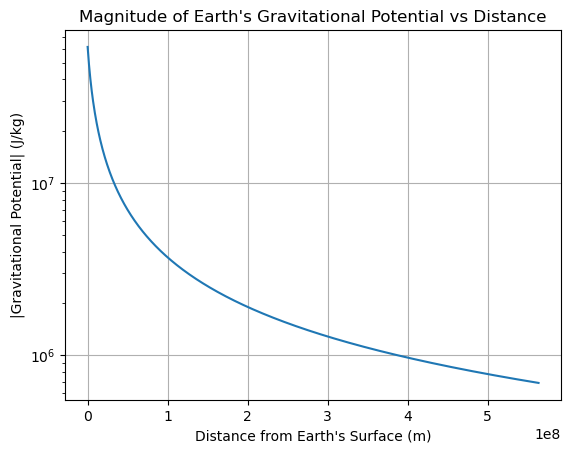

In [4]:
r_vals = np.linspace(R_E, 1.5*d_EM, 1000)

potentials = []
for r in r_vals:
    phi = gravitational_potential(M_E, (0,0), (r,0))
    potentials.append(abs(phi))


fig, ax = plt.subplots()
ax.plot(r_vals - R_E, potentials)
ax.set_yscale("log")
ax.set_xlabel("Distance from Earth's Surface (m)")
ax.set_ylabel("|Gravitational Potential| (J/kg)")
ax.set_title("Magnitude of Earth's Gravitational Potential vs Distance")
ax.grid(True)
plt.show()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

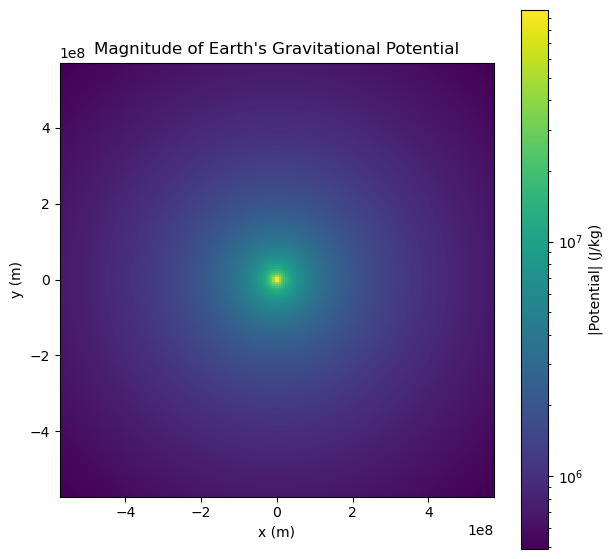

In [5]:
x = np.linspace(-1.5*d_EM, 1.5*d_EM, 200)
y = np.linspace(-1.5*d_EM, 1.5*d_EM, 200)
X, Y = np.meshgrid(x, y)
absPhi = np.zeros_like(X)
for i in range(len(x)):
    for j in range(len(y)):
        absPhi[j,i] = abs(gravitational_potential(M_E, (0,0), (X[j,i], Y[j,i])))


fig, ax = plt.subplots(figsize=(7,7))
pcm = ax.pcolormesh(X, Y, absPhi, norm=LogNorm(), shading="auto")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Magnitude of Earth's Gravitational Potential")
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("|Potential| (J/kg)")
plt.show()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

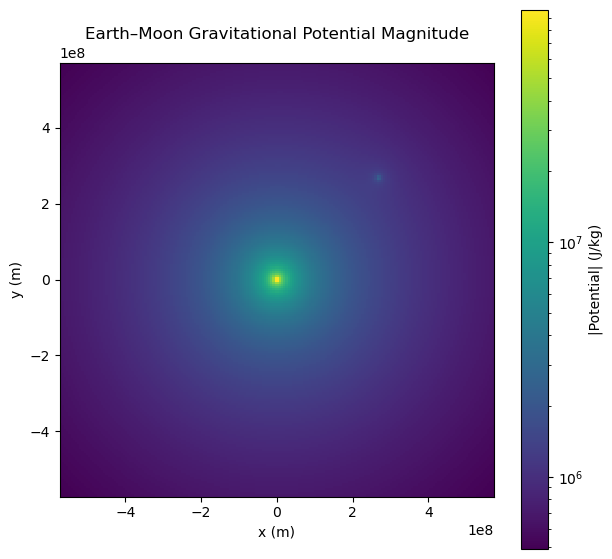

In [6]:
x_M = d_EM/np.sqrt(2)
y_M = d_EM/np.sqrt(2)

x = np.linspace(-1.5*d_EM, 1.5*d_EM, 200)
y = np.linspace(-1.5*d_EM, 1.5*d_EM, 200)
X, Y = np.meshgrid(x, y)
absPhi = np.zeros_like(X)
for i in range(len(x)):
    for j in range(len(y)):
        phi_E = gravitational_potential(M_E,(0,0),(X[j,i],Y[j,i]))
        phi_M = gravitational_potential(M_M,(x_M,y_M),(X[j,i],Y[j,i]))
        absPhi[j,i] = abs(phi_E + phi_M)

fig, ax = plt.subplots(figsize=(7,7))
pcm = ax.pcolormesh(X, Y, absPhi, norm=LogNorm(), shading="auto")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Earth–Moon Gravitational Potential Magnitude")
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("|Potential| (J/kg)")
plt.show()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

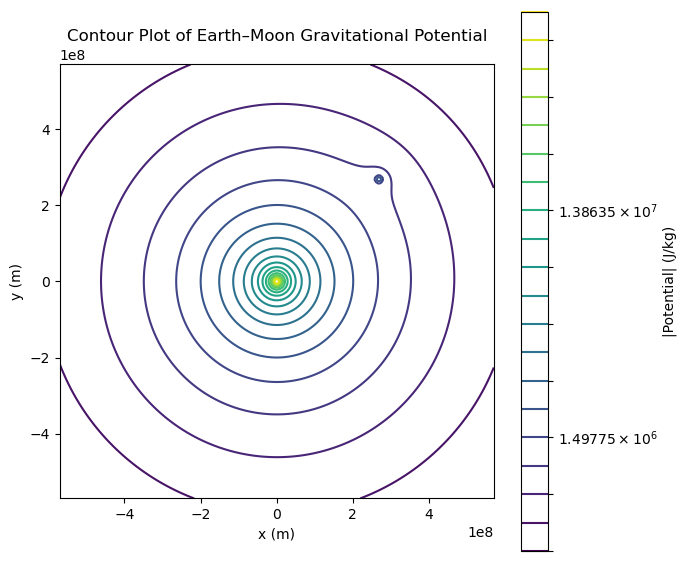

In [7]:
fig, ax = plt.subplots(figsize=(7,7))
levels = np.logspace(np.log10(absPhi.min()), np.log10(absPhi.max()), 20)
cont = ax.contour(X, Y, absPhi, levels=levels, norm=LogNorm())
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Contour Plot of Earth–Moon Gravitational Potential")
cbar = fig.colorbar(cont, ax=ax)
cbar.set_label("|Potential| (J/kg)")
plt.show()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def gravitational_force(
    M1: float,
    m2: float,
    pos1: tuple[float, float],
    pos2: tuple[float, float]
) -> tuple[float, float]:
    """
    Compute the gravitational force exerted by mass M1 on mass m2.

    Parameters
    ----------
    M1 : float
        Mass producing the gravitational field (kg)
    m2 : float
        Mass experiencing the force (kg)
    pos1 : tuple[float, float]
        (x, y) position of the source mass (m)
    pos2 : tuple[float, float]
        (x, y) position of the second mass (m)

    Returns
    -------
    tuple[float, float]
        Components of the gravitational force (Fx, Fy) in Newtons.
    """

    if not isinstance(M1,(int,float)):
        raise TypeError("M1 must be numeric")

    if M1 <= 0:
        raise ValueError("M1 must be nonzero, mass cannot be negative")

    if not isinstance(m2,(int,float)):
        raise TypeError("m2 must be numeric")
         
    if m2 <= 0:
        raise ValueError("m2 must be nonzero, mass cannot be negative")

    if not isinstance(pos1,tuple) or len(pos1)!=2:
        raise TypeError("pos1 must be a tuple of length 2")

    if not isinstance(pos2,tuple) or len(pos2)!=2:
        raise TypeError("pos2 must be a tuple of length 2")

    if not all(isinstance(v,(int,float)) for v in pos1):
        raise TypeError("pos1 values must be numeric")
 
    if not all(isinstance(v,(int,float)) for v in pos2):
        raise TypeError("pos2 values must be numeric")

    x1,y1 = pos1
    x2,y2 = pos2

    dx = x2 - x1
    dy = y2 - y1

    r = np.sqrt(dx**2 + dy**2)
 
    if r == 0:
        return np.nan, np.nan

    Fx = -G*M1*m2*dx/r**3
    Fy = -G*M1*m2*dy/r**3

    return Fx,Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

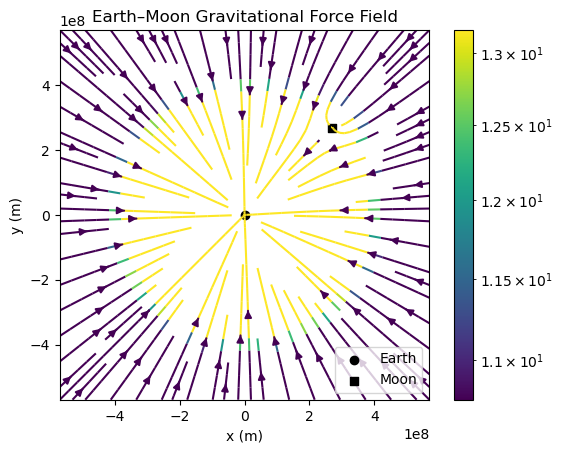

In [9]:
x_M = d_EM/np.sqrt(2)
y_M = d_EM/np.sqrt(2)
x = np.linspace(-1.5*d_EM, 1.5*d_EM, 60)
y = np.linspace(-1.5*d_EM, 1.5*d_EM, 60)
X, Y = np.meshgrid(x, y)

Fx = np.zeros_like(X)
Fy = np.zeros_like(X)

for i in range(len(x)):
    for j in range(len(y)):

        FxE, FyE = gravitational_force(M_E, 5500, (0,0), (X[j,i], Y[j,i]))
        FxM, FyM = gravitational_force(M_M, 5500, (x_M,y_M), (X[j,i], Y[j,i]))

        Fx[j,i] = FxE + FxM
        Fy[j,i] = FyE + FyM
Fmag = np.sqrt(Fx**2 + Fy**2)
fig, ax = plt.subplots()
strm = ax.streamplot(X, Y, Fx, Fy, color=Fmag, norm=LogNorm())
fig.colorbar(strm.lines, ax=ax)
ax.scatter(0,0,color="black",marker="o",label="Earth")
ax.scatter(x_M,y_M,color="black",marker="s",label="Moon")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Earth–Moon Gravitational Force Field")
ax.legend(loc="lower right")
plt.show()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

### Derivation of the Earth–Moon Balance Point

The balance point occurs where the gravitational forces from the Earth and Moon are equal in magnitude.

$$
F_E = F_M
$$

Using Newton's law of gravitation:

$$
F = \frac{GMm}{r^2}
$$

For the Earth and Moon we have

$$
\frac{G M_E m}{r^2} = \frac{G M_M m}{(d_{EM} - r)^2}
$$

Cancel the common factors $G$ and $m$:

$$
\frac{M_E}{r^2} = \frac{M_M}{(d_{EM}-r)^2}
$$

Take the square root of both sides:

$$
\frac{\sqrt{M_E}}{r} = \frac{\sqrt{M_M}}{d_{EM}-r}
$$

Multiply both sides by the denominators:

$$
\sqrt{M_E}(d_{EM}-r) = \sqrt{M_M}r
$$

Expand:

$$
\sqrt{M_E}d_{EM} - \sqrt{M_E}r = \sqrt{M_M}r
$$

Collect terms in $r$:

$$
\sqrt{M_E}d_{EM} = r(\sqrt{M_E} + \sqrt{M_M})
$$

Solve for $r$:

$$
r = \frac{\sqrt{M_E}d_{EM}}{\sqrt{M_E}+\sqrt{M_M}}
$$

This gives the radial distance from the Earth to the balance point along the Earth–Moon line.

And your updated plot, including the balance point, goes in the cell below.

Balance point distance from Earth: 3.42e+08 meters


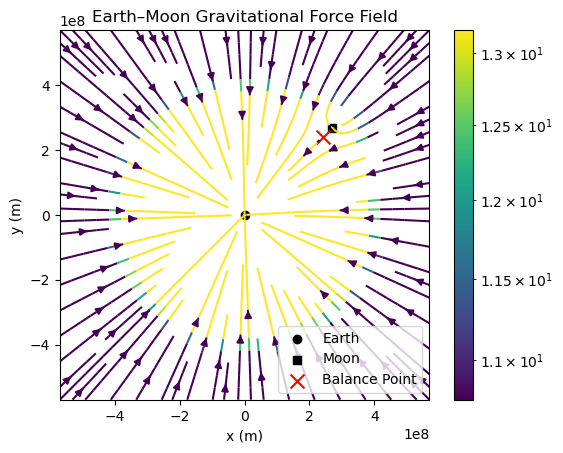

In [10]:
r_balance = (np.sqrt(M_E)*d_EM)/(np.sqrt(M_E)+np.sqrt(M_M))

x_balance = r_balance/np.sqrt(2)
y_balance = r_balance/np.sqrt(2)

print("Balance point distance from Earth:", f"{r_balance:.4g}", "meters")

fig, ax = plt.subplots()
strm = ax.streamplot(X, Y, Fx, Fy, color=Fmag, norm=LogNorm())
fig.colorbar(strm.lines, ax=ax)
ax.scatter(0,0,color="black",marker="o",label="Earth")
ax.scatter(x_M,y_M,color="black",marker="s",label="Moon")
ax.scatter(x_balance,y_balance,color="red",marker="x",s=100,label="Balance Point")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Earth–Moon Gravitational Force Field")
ax.legend(loc="lower right")

plt.show()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

### Discussion

The calculated balance point occurs at approximately

$$
r \approx 3.42 \times 10^8 \ \text{m}
$$

from the center of the Earth. Since the Earth–Moon distance is

$$
d_{EM} = 3.8 \times 10^8 \ \text{m},
$$

the balance point lies much closer to the Moon than to the Earth.

The distance from the Moon is approximately

$$
d_{EM} - r \approx 3.38 \times 10^7 \ \text{m}.
$$

This occurs because the Earth's mass

$$
M_E = 5.9 \times 10^{24} \ \text{kg}
$$

is much larger than the Moon's mass

$$
M_M = 7.3 \times 10^{22} \ \text{kg}.
$$

Because gravitational force is proportional to mass, the weaker gravitational pull of the Moon must act over a shorter distance to balance the stronger gravitational pull of the Earth.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

In [11]:
m_0 = 2.8e6 #kg
m_f = 7.5e5 #kg
m_dot = 1.3e4 #kg/s
v_e = 2.4e3 #m/s
g = 9.81 #m/s^2

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [12]:
T = (m_0 - m_f)/m_dot
print(T)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [13]:
def delta_v(t: float, m0: float, mf: float, mdot: float, ve: float, g: float) -> float:
    """
    Compute the rocket velocity change Δv at time t using the rocket equation.

    Parameters
    ----------
    t : float
        Time since launch (s)
    m0 : float
        Initial rocket mass (kg)
    mf : float
        Final rocket mass after burn (kg)
    mdot : float
        Fuel burn rate (kg/s)
    ve : float
        Exhaust velocity (m/s)
    g : float
        Gravitational acceleration (m/s^2)

    Returns
    -------
    float
        Velocity change Δv at time t (m/s)
    """

    if not isinstance(t,(int,float)):
        raise TypeError("t must be numeric")

    if not all(isinstance(v,(int,float)) for v in (m0,mf,mdot,ve,g)):
        raise TypeError("All parameters must be numeric")

    if m0 <= 0 or mf <= 0:
        raise ValueError("Mass values must be positive")

    if mdot <= 0:
        raise ValueError("Burn rate must be positive")

    T = (m0 - mf)/mdot

    if t < 0:
        raise ValueError("Time cannot be negative")

    if t > T:
        return 0

    m = m0 - mdot*t
    dv = ve*np.log(m0/m) - g*t

    return dv

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [14]:
height, err = quad(delta_v, 0, T, args=(m_0, m_f, m_dot, v_e, g))

print("height =", f"{height:.2g}", "meters")

height = 7.4e+04 meters


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

### Comparison with Test Data

The calculated burn time is

$$
T \approx 158 \text{ s}
$$

which is very close to the reported test burn time of approximately \(160\) seconds.

The calculated altitude at burnout is

$$
h \approx 7.4\times10^4 \text{ m}
$$

or about \(74\) km. The reported test result was approximately \(70\) km.

Our model slightly overestimates the altitude. This difference is expected because the calculation neglects several real physical effects such as atmospheric drag and variations in thrust during the burn. Drag reduces the rocket's velocity and therefore lowers the altitude reached during the burn. The simplified model also assumes constant exhaust velocity and burn rate, which are only approximations in a real rocket engine.